In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sympy as sp

In [ ]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 5.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


  Cloning https://github.com/vanbreugel-lab/pybounds to /tmp/pip-req-build-xxdgiehh
  Running command git clone --filter=blob:none --quiet https://github.com/vanbreugel-lab/pybounds /tmp/pip-req-build-xxdgiehh
  Resolved https://github.com/vanbreugel-lab/pybounds to commit 96f12039ac9e1e3ef4381cd09a026f6bbf70ad5c
  Preparing metadata (setup.py) ... done
  Created wheel for pybounds: filename=pybounds-0.0.13-py3-none-any.whl size=19546 sha256=e0d59d5d0c43824d88fd965643d447d608f0639bb49901e30ff8037a0ec17412
  Stored in directory: /tmp/pip-ephem-wheel-cache-fusf21j2/wheels/cb/f8/fb/ff1887f9a2f35c3edad7b1acb7da69437c1fd8d885a800578d
Successfully built pybounds


### Import plotting utilities and planar drone locally or from github

Local import failed: No module named 'model_simulation'
Fetching from: https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/model_simulation.py
Response: 200


/content/model_simulation.py:82: SyntaxWarning: invalid escape sequence '\m'
  \mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
/content/model_simulation.py:270: SyntaxWarning: invalid escape sequence '\m'
  \mathbf{y} =


Fetching from: 
<Response [200]>
Local import failed: No module named 'dynamics_utility'
Fetching from: https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/dynamics_utility.py
Response: 200


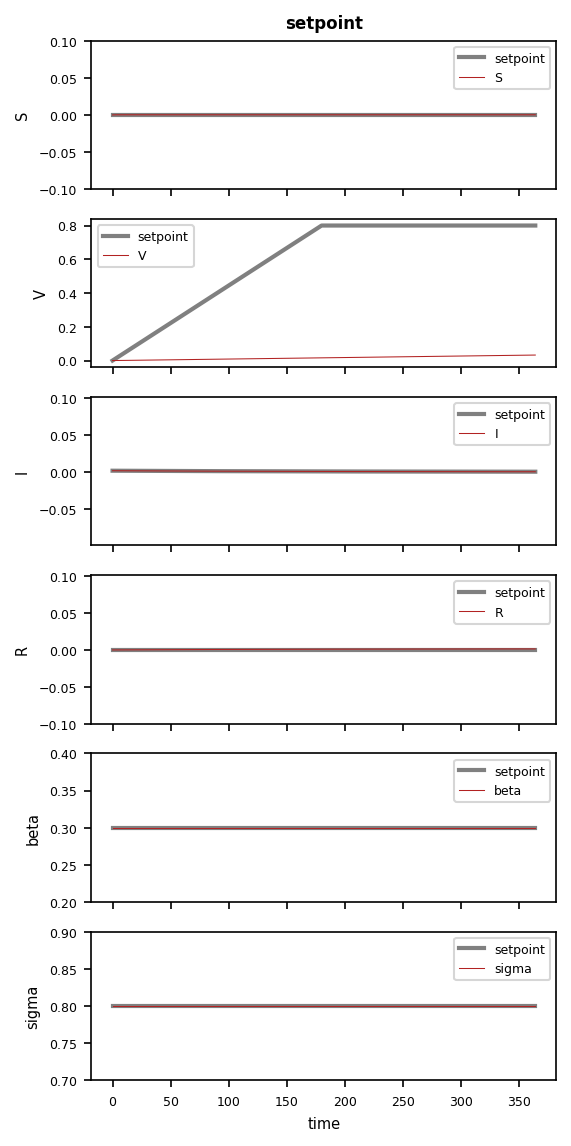

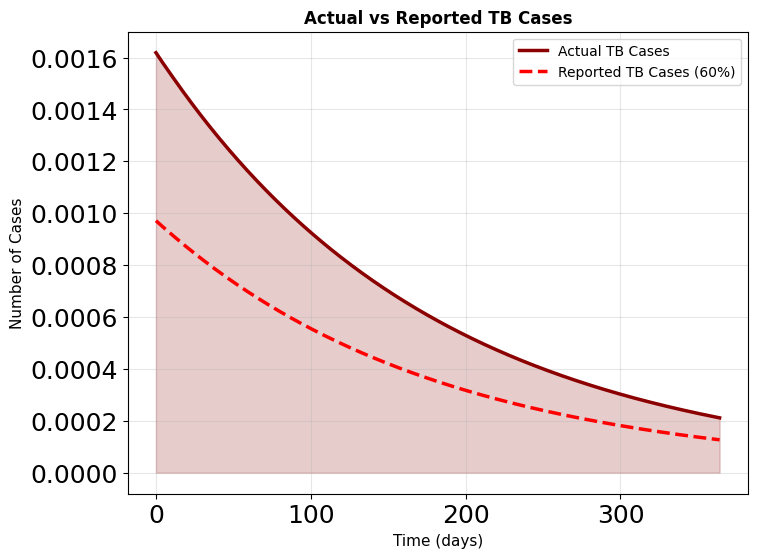

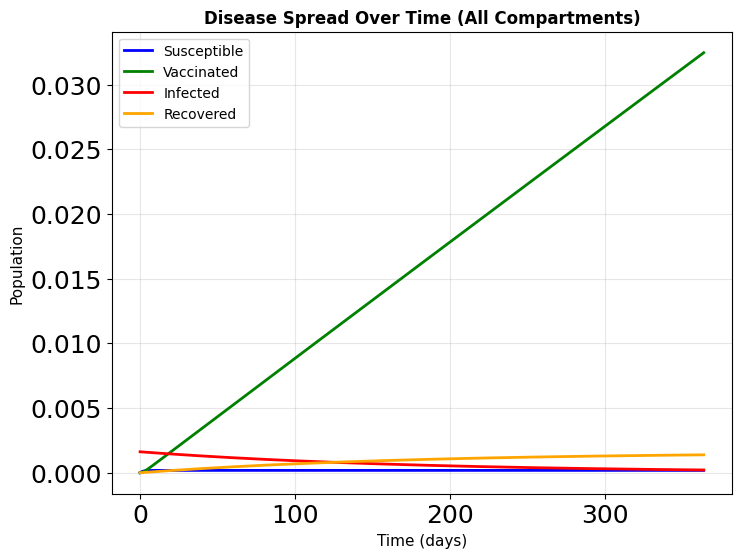

In [ ]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    try:  # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package
    except Exception as e:  # get the file from github
        print(f"Local import failed: {e}")
        if giturl is None:
            giturl = "https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/" + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from:', giturl)
        print('Response:', r.status_code)

        if r.status_code != 200:
            raise Exception(f"Failed to fetch {giturl}: {r.status_code}")

        # Clean the code: remove lines with Jupyter shell commands
        code_text = r.text
        cleaned_lines = []
        for line in code_text.split('\n'):
            # Skip lines that start with ! (after stripping whitespace)
            if not line.strip().startswith('!'):
                cleaned_lines.append(line)

        cleaned_code = '\n'.join(cleaned_lines)

        # Store the cleaned file
        with open(package_name + '.py', 'w') as f:
            f.write(cleaned_code)  # Write cleaned_code, not r.text!

        # import the module
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

# Now import your modules
tb_simulation = import_local_or_github('tb_simulation', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
dynamics_utility = import_local_or_github('dynamics_utility', directory='../Utility')

#### Given the planar d dynamics

$$
\mathbf{\dot{x}} =
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

#### Consider the following :

$
\mathbf{y_a} = \begin{bmatrix}
0.6\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{V}/N
\end{bmatrix}
$

$
\mathbf{y_b} = \begin{bmatrix}
\bbox[pink]{\beta}(1-\bbox[lightgreen]{\kappa})\bbox[yellow]{S}\bbox[yellow]{I} + \bbox[pink]{\sigma}\bbox[pink]{\beta}(1-\bbox[lightgreen]{\kappa})\bbox[yellow]{V}\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{I}
\end{bmatrix}
$

In [ ]:
f = tb_simulation.F().f
h_a = planar_drone.H('h_gps').h
h_b = planar_drone.H('h_camera_theta_k').h
h_c = planar_drone.H('h_camera_imu').h

AttributeError: module 'model_simulation' has no attribute 'F'

### Linearize the dynamics and measurement function

We need linearized dynamics of the form:

$
\mathbf{x_{k+1}} = A\mathbf{x_k} + B\mathbf{u_k}
$

$
\mathbf{y_k} = C\mathbf{x_k} + D\mathbf{u_k}
$

We will do that numerically using the same functions as before.

In [ ]:
jacobian_numerical = dynamics_utility.jacobian_numerical
rk4_discretize = dynamics_utility.rk4_discretize

In [ ]:
N = 223000000

In [ ]:
# initial condition

x0 = np.array([
    (N - 158330000 - 361000 - 12000000),
    158330000,
    361000,
    12000000,
    0.3,
    0.8
])
u0 = np.array([0, 0])

In [ ]:
def f_discrete(x, u):
    dt = 0.1
    return rk4_discretize(f, x, u, dt)

In [ ]:
A, B = jacobian_numerical(f_discrete, x0, u0)

In [ ]:
C_a, D_a = jacobian_numerical(h_a, x0, u0)
C_b, D_b = jacobian_numerical(h_b, x0, u0)


# Exercises

1. Determine the rank of the observability matrix for each measurement option. Which ones are observable?
2. Determine the observability Gramian for each measurement option:
  * Analyze the eigenvalues/eigenvectors to determine the most observable state combinations
  * Analyze the matrix inverse of the Gramian to determien the most observable individual states

3. Do your results agree with your Kalman filter from the prior lesson?  